<div style="border:4px solid red">

For all homework blocks that have numerical answers, name the variable the hw plus the homework number.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import special

# Review
<details open>
<summary>Click to collapse</summary>

The Sommerfeld diffraction integral is

$E(P_o) = \frac{z}{j\lambda} \int_{\Sigma} E_{inc} \frac{e^{jkr_{01}}}{r_{01}^2} dx' dy'$


The Fresnel diffraction equation is

$E(x,y,z) = \frac{e^{jkz}}{j\lambda z} 
\iint_{\Sigma} E(x',y') 
\exp\left[j\frac{k}{2z}\left((x-x')^2 + (y-y')^2\right)\right]
dx' dy'$


The Fresnel diffraction at focus of lens

$E(x,y,z) = \iint_{\Sigma} E_o(x',y')  
\exp \left( -j\frac{2 \pi}{ \lambda \, f} \left(x \, x' \right) \right) dx' \exp \left( -j\frac{2 \pi}{ \lambda \, f} \left(y \, y' \right) \right) dx' dy'$


Thus, at the focus of the lens the diffraction pattern can be solved using Fourier transforms with the relationships of

$f_x = \frac{x}{\lambda f}, \quad f_y = \frac{y}{\lambda f}$


The Fraunhoffer diffraction equation is 

$E(x,y,z) =
\frac{e^{jkz}}{j\lambda z} e^{j\frac{k}{2z}(x^2+y^2)}
\iint_{\Sigma} E(x',y')
\exp\left[-j\frac{k}{z}(xx' + yy')\right] dx' dy'$

$E(x,y,z) = \left( \mathcal{F}_x \{ E(x') \} \right) \left( \mathcal{F}_y \{ E(y') \} \right)$

with $f_x=\frac{x}{\lambda z}$ and $f_y=\frac{y}{\lambda z}$

## Basic Fourier Transform Relations


If $f(x) \leftrightarrow F(f)$:

-   $K f(x) \leftrightarrow K F(f)$
-   $f(ax) \leftrightarrow \frac{1}{|a|} F\!\left(\frac{f}{a}\right)$
-   $f(x-x_0) \leftrightarrow F(f)e^{-j2\pi f x_0}$
-   $e^{j2\pi f_0 x} f(x) \leftrightarrow F(f-f_0)$

## Fourier Transform Pairs

| Function | Fourier Transform |
|-----------|------------------|
| $\delta(x)$ | $1$ |
| $A$ | $2\pi A\,\delta(f)$ |
| $\cos(\omega_0 x)$ | $\pi[\delta(f-\omega_0)+\delta(f+\omega_0)]$ |
| $\sin(\omega_0 x)$ | $j\pi[\delta(f-\omega_0)-\delta(f+\omega_0)]$ |
| $\text{rect}(x)$ | $\text{sinc}(f)$ |
| $\Lambda(x)$ | $\text{sinc}^2(f)$ |
| $\text{circ}(r/R)$ | $\pi R^2 \dfrac{J_1(2\pi R f)}{2\pi R f}$ |
| $e^{-\pi x^2}$ | $e^{-\pi f^2}$ |
| $e^{j\pi x^2}$ | $e^{j\pi/4} e^{-j\pi f^2}$ |
| $\sum_{n=-S}^{S}\delta(x-n)$ | $\dfrac{\sin(M\pi f)}{\sin(\pi f)}$, $M=2S+1$ |
| $\sum_{n=-\infty}^{\infty}\delta(x-n)$ | $\sum_{n=-\infty}^{\infty}\delta(f-n)$ |


$\text{rect}(x) = \begin{cases}
1 & |x| \le \frac{1}{2} \\
0 & \text{otherwise}
\end{cases}$

$\text{sinc}(x)=\frac{\sin (\pi x)}{\pi x}$

$\Lambda(x) = \begin{cases}
1-|x| & |x| \le 1 \\
0 & \text{otherwise}
\end{cases}$

$\text{circ}\left(\sqrt{x^2 + y^2}\right) = \begin{cases}
1 & \sqrt{x^2 + y^2} \le 1 \\
0 & \text{otherwise}
\end{cases}$

$\int_{-\infty}^{\infty} \mathrm{sinc}(x)\, dx = 1$

$\int_{-\infty}^{\infty} \mathrm{sinc}^2(x)\, dx = 1$

$\int_{0}^{\infty} \left| \frac{J_1(x)}{x} \right|^2 dx = \frac{4}{3\pi}$

$\int_{0}^{\infty} x \left| \frac{J_1(x)}{x} \right|^2 dx = \frac{1}{2}$

$sinc(0)=1$

$\frac{J_1(0)}{0}=\frac{1}{2}$

## Grating

1. Grating order direction: $\sin\theta_m = \sin\theta_i + m\frac{\lambda}{\Lambda}$
2. Efficiency of each order: $\eta_m = A \left( f_x=\frac{m}{\Lambda} \right)$
3. Shape of each order: Same as if there was no grating

</details>

## Binary Phase Grating (50% Fill Factor)

The Fourier transform of a single period defines the efficiency of each diffracted order.  Here is a picture of a single period of a binary phase grating with a 50% fill factor.

<img src="binary_phase.jpg" width="300">

There are two regions. Define each region with a rect function and then add them together. Similar to the double-slit problem, we convert this into a sine or cosine form. Therefore, we define the x-axis to be centered.

(1) Ridge

Transmission:

$t_1(x) = e^{j \phi_1} rect \left(\frac{x + \Lambda/4}{\Lambda/2}\right)$

The phase term is the relative phase accumulated by propagating through the glass ridge.  The glass has a thickness of $d$.  So, the phase term is given by

$e^{j \phi_1}=e^{j \frac{2 \pi}{\lambda} d \, n}$

resulting in 

$t_1(x) = e^{j \frac{2 \pi}{\lambda} d \, n} rect \left(\frac{x + \Lambda/4}{\Lambda/2}\right)$


(2) Groove

$t_2(x) = e^{i\phi_2} rect \left(\frac{x - \Lambda/4}{\Lambda/2}\right)$

The groove also has a thickness of d but it is air.  So, the phase term is given by

$e^{j \phi_2}=e^{j \frac{2 \pi}{\lambda} d}$

resulting in 

$t_2(x)=e^{j \frac{2 \pi}{\lambda} d} rect \left(\frac{x - \Lambda/4}{\Lambda/2}\right)$

The total transmission of the single grating period is

$t(x)= a(x) = 
e^{j \frac{2 \pi}{\lambda} d \, n} rect \left(\frac{x + \Lambda/4}{\Lambda/2}\right)
+
e^{j \frac{2 \pi}{\lambda} d} rect \left(\frac{x - \Lambda/4}{\Lambda/2}\right)$


Fourier transform is

$T(f_x) = \frac{\Lambda}{2} \, e^{j \frac{2 \pi}{\lambda} d \, n} \, e^{j 2 \pi f_x \frac{\Lambda}{4}} sinc \left( \frac{\Lambda}{2} f_x \right)
+
\frac{\Lambda}{2} \, e^{-j \frac{2 \pi}{\lambda} d} \, e^{-j 2 \pi f_x \frac{\Lambda}{4}} sinc \left( \frac{\Lambda}{2} f_x \right)$

Efficiency of diffracted orders 

$\eta_m = T \left( f_x=\frac{m}{\Lambda} \right)$

Dropping common amplitude term

$\eta_m = e^{j \frac{2 \pi}{\lambda} d \, n} \, e^{j 2 \pi \frac{m}{\Lambda} \frac{\Lambda}{4}} sinc \left( \frac{\Lambda}{2} \frac{m}{\Lambda} \right)
+
e^{-j \frac{2 \pi}{\lambda} d} \, e^{-j 2 \pi \frac{m}{\Lambda}  \frac{\Lambda}{4}} sinc \left( \frac{\Lambda}{2} \frac{m}{\Lambda} \right)$

$\eta_m = \exp \left( j \frac{2 \pi}{\lambda} d n \right) \exp \left( j \frac{\pi m}{2} \right) \text{sinc} \left( \frac{m}{2}\right) + \exp \left(-j \frac{2 \pi}{\lambda} d \right) \exp \left( -j \frac{\pi m}{2} \right) \text{sinc} \left( \frac{m}{2} \right)$

Drop common amplitude term

$\eta_m = \exp \left( j \frac{2 \pi}{\lambda} d n \right) \exp \left( j \frac{\pi m}{2} \right) + \exp \left(-j \frac{2 \pi}{\lambda} d \right) \exp \left( -j \frac{\pi m}{2} \right) $

Factor out a phase term to make the phase terms equal but opposite

$\eta_m = exp\left(j \left(\frac{2\pi}{\lambda} d n + \frac{\pi m}{2}\right)\right) + exp\left(-j \left(\frac{2\pi}{\lambda} d + \frac{\pi m}{2}\right)\right)$

$\eta_m = exp\left(j \frac{\pi}{\lambda} d (n + 1)\right) \left[
exp\left(j \left(\frac{\pi}{\lambda} d (n - 1) + \frac{\pi m}{2}\right)\right) + exp\left(-j \left(\frac{\pi}{\lambda} d (n - 1) + \frac{\pi m}{2}\right)\right) \right]$

$\eta_m =exp\left(j \frac{\pi}{\lambda} d (n + 1)\right)
\cos\left(\frac{\pi}{\lambda} d (n - 1) + \frac{\pi m}{2}\right)$

Elimiante the common phase term to get

$\eta_m = \cos\left(\frac{\pi}{\lambda} d (n - 1) + \frac{\pi m}{2}\right)$


<div style="border:4px solid red">

**HW1:** A binary phase grating has a wavelength of $\lambda=670nm$, a thickness of $d=500nm$, and refractive index of $n=1.51$.  Create a stem plot of the diffraction efficiencies.  What is the fraction of the power in the $m=0$ order?

hw1 (power fraction in m=0) = 0.134329


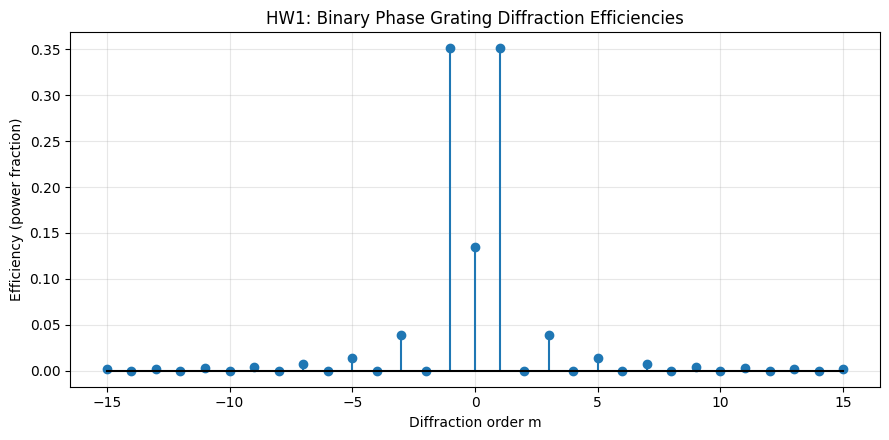

In [3]:
# HW1: Diffraction efficiencies for a 50% duty-cycle binary phase grating

# Given grating/material parameters
lam = 670e-9      # wavelength [m]
d = 500e-9        # grating thickness [m]
n = 1.51          # ridge refractive index (groove is air, n=1)

# Build enough diffraction orders so normalization is accurate
m_full = np.arange(-500, 501)

# From the derivation above, the order amplitude follows
# a_m ∝ sinc(m/2) * cos(pi*d*(n-1)/lam + pi*m/2)
# (Any global phase/common scale is omitted because we normalize power afterward.)
phase_term = np.pi * d * (n - 1) / lam + (np.pi / 2) * m_full
a_m = np.sinc(m_full / 2) * np.cos(phase_term)

# Diffraction efficiency (power fraction) is proportional to |a_m|^2
eta = np.abs(a_m) ** 2

# Normalize so total plotted/used power sums to 1
eta = eta / np.sum(eta)

# Required homework variable: fraction of power in the m=0 order
hw1 = float(eta[m_full == 0][0])
print(f"hw1 (power fraction in m=0) = {hw1:.6f}")

# Plot a readable order window
m_plot_min, m_plot_max = -15, 15
mask = (m_full >= m_plot_min) & (m_full <= m_plot_max)

plt.figure(figsize=(9, 4.5))
markerline, stemlines, baseline = plt.stem(m_full[mask], eta[mask], basefmt="k-")
plt.setp(markerline, markersize=6)
plt.setp(stemlines, linewidth=1.5)
plt.xlabel("Diffraction order m")
plt.ylabel("Efficiency (power fraction)")
plt.title("HW1: Binary Phase Grating Diffraction Efficiencies")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

<div style="border:4px solid red">

**HW2:** A binary phase grating has a wavelength of $\lambda=670\text{ nm}$ and a refractive index of $n=1.51$.  What thickness gives negligible power in the $m=0$ order?  Create a stem plot of the diffraction efficiencies.

hw2 (minimum thickness for negligible m=0) = 6.568627e-07 m (656.863 nm)
Computed m=0 power fraction = 2.588e-32


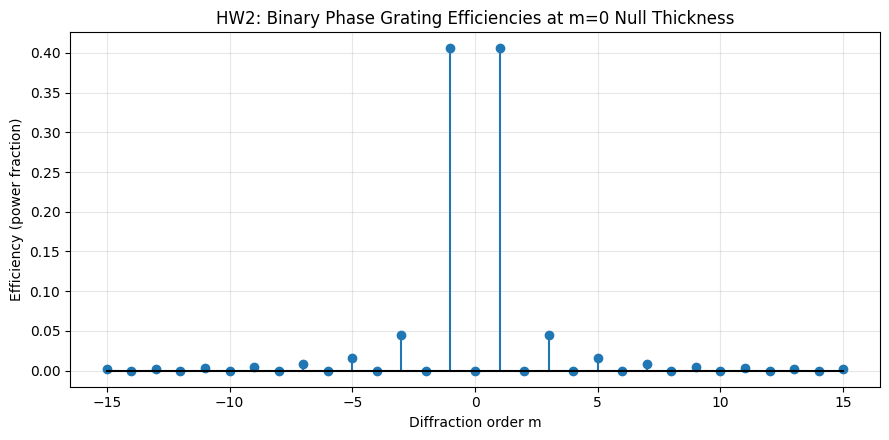

In [4]:
# HW2: Thickness that gives negligible power in the m=0 order

# Given constants
lam = 670e-9   # wavelength [m]
n = 1.51       # ridge refractive index

# From the derived HW1 amplitude expression, for m=0 we have
 # a_0 ∝ cos(pi*d*(n-1)/lam)
# To suppress m=0 power, set this cosine to zero:
 # pi*d*(n-1)/lam = (2k+1)pi/2  ->  d = (2k+1)*lam/(2*(n-1))
# Choose the smallest positive thickness (k=0).
hw2 = lam / (2 * (n - 1))
print(f"hw2 (minimum thickness for negligible m=0) = {hw2:.6e} m ({hw2*1e9:.3f} nm)")

# Compute diffraction efficiencies using the same derived amplitude formula
m_full = np.arange(-500, 501)
phase_term = np.pi * hw2 * (n - 1) / lam + (np.pi / 2) * m_full
a_m = np.sinc(m_full / 2) * np.cos(phase_term)
eta = np.abs(a_m) ** 2
eta = eta / np.sum(eta)

# Verify that the central order is essentially zero
eta_m0 = float(eta[m_full == 0][0])
print(f"Computed m=0 power fraction = {eta_m0:.3e}")

# Plot efficiencies over a practical order window
m_plot_min, m_plot_max = -15, 15
mask = (m_full >= m_plot_min) & (m_full <= m_plot_max)

plt.figure(figsize=(9, 4.5))
markerline, stemlines, baseline = plt.stem(m_full[mask], eta[mask], basefmt="k-")
plt.setp(markerline, markersize=6)
plt.setp(stemlines, linewidth=1.5)
plt.xlabel("Diffraction order m")
plt.ylabel("Efficiency (power fraction)")
plt.title("HW2: Binary Phase Grating Efficiencies at m=0 Null Thickness")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

<div style="border:4px solid red">

**HW3:** When determining the efficiency, we need to consider the total number of orders to sum.  A phase grating is fabricated on a glass substrate with $n=1.5$ and has a period of $\Lambda=70\,\mu\text{m}$. A laser beam with wavelength $\lambda=670\text{ nm}$ is normally incident on the grating.  What is the maximum number of orders (in air) produced by the grating?

In [5]:
# Maximum order number occurs when the parallel component of the diffracted wave is equal to the wavenumber of the incident beam
# So it's m__max = k/k_grating
# Or lam_grating / lam_incident

lam_incident = 670e-9
lam_grating = 70e-6
m_max = lam_grating / lam_incident
m_max_int = int(np.floor(m_max))
hw3 = 2 * m_max_int + 1  # Total number of orders is 2*m_max_int + 1 (including negative and zero)
print(f"hw3 (maximum diffraction order) = {hw3:.2f}")


hw3 (maximum diffraction order) = 209.00


<div style="border:4px solid red">

**HW4:** Create a function that calculates the diffraction efficiency for a grating with the period shown in this figure.

<img src="picture1.jpg" width="500">

The calculation has the following fixed parameters: wavelength $\lambda=670\text{ nm}$, refractive index $n=1.5$, and maximum order number $m=7$. These parameters should be hard coded into the function. The function should take a single argument

$[d, xf]$, 

where $d$ is the thickness of the grating and $xf$ is a vector of the grating transition points. Here are the constraints:
- The first element must be zero.
- The last element must be the grating period.
- The first section must be a ridge.
- The function should return a vector with the normalized efficiencies.
- All values in units of meters.

From the figure you

grating=np.array([0.4e-6, 0, 6e-6, 18e-6, 52e-6, 64e-6, 70e-6])

The function must produce the following normalized efficiencies.

0.0017, 0.0005, 0.0074, 0.0171, 0.2799, 0.1497, 0.1503, 1.0000, 0.1503, 0.1497, 0.2799, 0.0171, 0.0074, 0.0005, 0.0017
		



In [36]:
#Code for HW4

#ADD FUNCTION
def grating_calc(val):
    m_max = 7
    lam = 0.67e-6
    n = 1.5
    
    # Extract thickness and transition points
    d = val[0]
    xf = val[1:]
    
    # Grating period (last transition point)
    Lambda = xf[-1]
    
    # Initialize amplitude array for orders m = -m_max to m_max
    m_orders = np.arange(-m_max, m_max + 1)  # 15 orders total
    amplitude = np.zeros(len(m_orders), dtype=complex)
    
    # Process each section between transition points
    ridge = True  # First section is a ridge
    for i in range(len(xf) - 1):
        x1 = xf[i]
        x2 = xf[i + 1]
        width = x2 - x1
        x_center = (x1 + x2) / 2
        
        # Phase shift for this section
        if ridge:
            phase = 2 * np.pi * d * n / lam  # Ridge: glass with refractive index n
        else:
            phase = 2 * np.pi * d / lam       # Groove: air (n=1)
        
        # Contribution to each diffraction order
        for j, m in enumerate(m_orders):
            fx = m / Lambda  # Spatial frequency for this order
            
            # Fourier transform of rectangular transmission
            sinc_val = np.sinc(width * fx)
            spatial_phase = np.exp(-1j * 2 * np.pi * fx * x_center)
            amplitude[j] += np.exp(1j * phase) * width * sinc_val * spatial_phase
        
        ridge = not ridge
    
    # Calculate power (squared magnitude)
    power = np.abs(amplitude) ** 2
    
    # Normalize to maximum value
    eff = power / np.max(power)
    
    # Round to 4 decimal places to match expected precision
    eff = np.round(eff, 4)
    
    return eff

grating=np.array([0.4e-6, 0, 6e-6, 18e-6, 52e-6, 64e-6, 70e-6])
hw4=grating_calc(grating)
correct=np.array([0.0017, 0.0005, 0.0074, 0.0171, 0.2799, 0.1497, 0.1503, 1.0000, 0.1503, 0.1497, 0.2799, 0.0171, 0.0074, 0.0005, 0.0017])

error=np.sum(np.abs(hw4-correct))
if error>1e-4:
    print("error=", error, "HW4 function is wrong")
else:
    print("error=", error, "HW4 function is correct")

error= 0.0 HW4 function is correct


In [37]:
# Detailed error analysis
print("Detailed comparison:")
print("m    | Computed  | Expected  | Error")
print("-----|-----------|-----------|----------")
for i in range(15):
    m = i - 7
    comp = hw4[i]
    exp = correct[i]
    err = abs(comp - exp)
    print(f"{m:3d}  | {comp:9.6f} | {exp:9.6f} | {err:9.6f}")
    
print(f"\nTotal error: {np.sum(np.abs(hw4-correct)):.6f}")
print(f"Tolerance: 1e-4")

Detailed comparison:
m    | Computed  | Expected  | Error
-----|-----------|-----------|----------
 -7  |  0.001700 |  0.001700 |  0.000000
 -6  |  0.000500 |  0.000500 |  0.000000
 -5  |  0.007400 |  0.007400 |  0.000000
 -4  |  0.017100 |  0.017100 |  0.000000
 -3  |  0.279900 |  0.279900 |  0.000000
 -2  |  0.149700 |  0.149700 |  0.000000
 -1  |  0.150300 |  0.150300 |  0.000000
  0  |  1.000000 |  1.000000 |  0.000000
  1  |  0.150300 |  0.150300 |  0.000000
  2  |  0.149700 |  0.149700 |  0.000000
  3  |  0.279900 |  0.279900 |  0.000000
  4  |  0.017100 |  0.017100 |  0.000000
  5  |  0.007400 |  0.007400 |  0.000000
  6  |  0.000500 |  0.000500 |  0.000000
  7  |  0.001700 |  0.001700 |  0.000000

Total error: 0.000000
Tolerance: 1e-4
